FileNotFoundError: [Errno 2] No such file or directory: 'output/zeros_riemann.png'

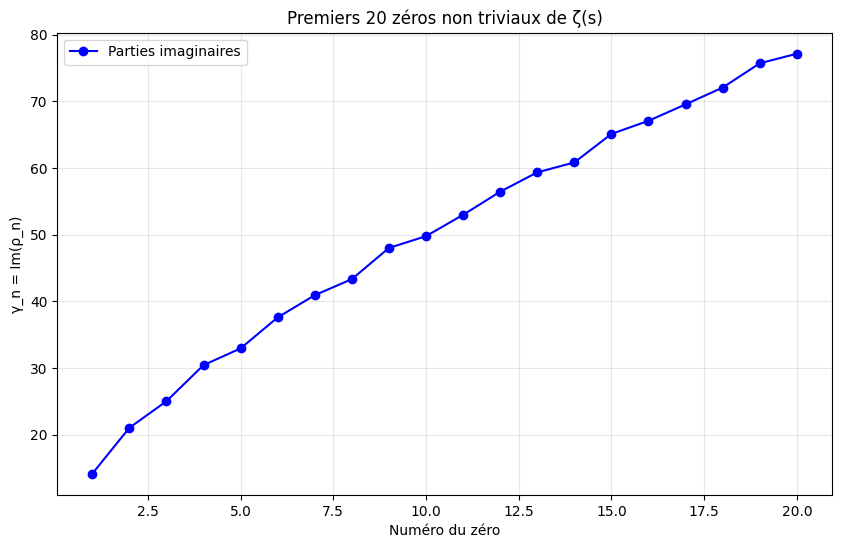

In [1]:
from mpmath import *
import matplotlib.pyplot as plt
import numpy as np

# Calcul des 20 premiers zéros
mp.dps = 30  # Précision
zeros = [zetazero(n) for n in range(1, 21)]
imags = [float(im(z)) for z in zeros]  # Parties imaginaires [web:21]

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), imags, 'bo-', label='Parties imaginaires')
plt.xlabel('Numéro du zéro')
plt.ylabel('γ_n = Im(ρ_n)')
plt.title('Premiers 20 zéros non triviaux de ζ(s)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('output/zeros_riemann.png')
plt.close()  # Fichier sauvé pour l'utilisateur

# PRNG : espacements normalisés -> bits
def prng_riemann(seed=42, length=100):
    """
    Générateur pseudo-aléatoire basé sur les espacements des zéros.
    - Normalise les espacements (moyenne ~1)
    - Bit = 1 si écart >1, 0 sinon
    - seed pour itérer ou étendre
    """
    np.random.seed(seed)  # Déterministe
    bits = []
    for i in range(length):
        n = (i // 2) % 20 + 1  # Cycle sur les 20 zéros
        if i % 2 == 1:  # Alterne écarts pairs/impairs pour plus de variété
            espacement = (imags[(n % 20)] - imags[(n-1) % 20]) / np.log(imags[(n % 20)])
        else:
            espacement = 1.0 / np.log(imags[n % 20])  # Approximation moyenne locale
        bit = 1 if espacement > 1 else 0
        bits.append(bit)
    return bits

# Exemple d'utilisation
bits = prng_riemann(length=50)
print("Premiers 50 bits:", ''.join(map(str, bits)))
print("Suite décimale approx:", int(''.join(map(str, bits[:32])), 2) / 2**32)

# Sauvegarde en CSV pour analyse
import pandas as pd
df = pd.DataFrame({'zero_num': range(1,21), 'imag': imags})
df.to_csv('output/riemann_zeros.csv', index=False)